## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from pathlib import Path

In [2]:
BASE      = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita")
AKITA_DIR = BASE / "optimizations/dots/results/dot_d50"
ALPHA_DIR = BASE / "analysis/alpha_genome_validation/dot_design"
PLOTS_DIR = Path("./../plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

FOLDS      = range(8)
MERGE_KEYS = ["chrom", "centered_start", "centered_end"]

In [3]:
akita_dfs = []
for fold in FOLDS:
    path = AKITA_DIR / f"fold{fold}_dot_scd_akita_results.tsv"
    fold_df = pd.read_csv(path, sep="\t")
    fold_df["fold"] = fold
    akita_dfs.append(fold_df)

akita_df = pd.concat(akita_dfs, ignore_index=True)

# Successful = dot score increased after optimization
akita_df["dot_score_diff"]     = akita_df["dot15_edited"] - akita_df["dot15_orig"]
akita_df["optimization_success"] = akita_df["dot_score_diff"] > 0

print(f"Loaded {len(akita_df)} Akita rows across {akita_df['fold'].nunique()} folds")
print(f"Successful optimizations: {akita_df['optimization_success'].sum()} / {len(akita_df)}")

Loaded 355 Akita rows across 8 folds
Successful optimizations: 307 / 355


In [4]:
alpha_dfs = []
for fold in FOLDS:
    path = ALPHA_DIR / f"fold{fold}_alphagenome_results.tsv"
    fold_df = pd.read_csv(path, sep="\t")
    alpha_dfs.append(fold_df)

alpha_df = pd.concat(alpha_dfs, ignore_index=True)
print(f"Loaded {len(alpha_df)} Alpha Genome rows across {alpha_df['fold'].nunique()} folds")

Loaded 355 Alpha Genome rows across 8 folds


In [6]:
merged_df = akita_df.merge(
    alpha_df[MERGE_KEYS + ["fold", "alpha_scd"]],
    on=MERGE_KEYS,
    how="inner",
    validate="1:1",
)

n_dropped = len(akita_df) - len(merged_df)
if n_dropped:
    print(f"WARNING: {n_dropped} rows lost in merge — check for locus mismatches")

succ_df = merged_df[merged_df["optimization_success"]].copy()
print(f"Merged: {len(merged_df)} rows total, {len(succ_df)} successful")

Merged: 355 rows total, 307 successful


Pearson R = 0.6965, p = 7.19e-46


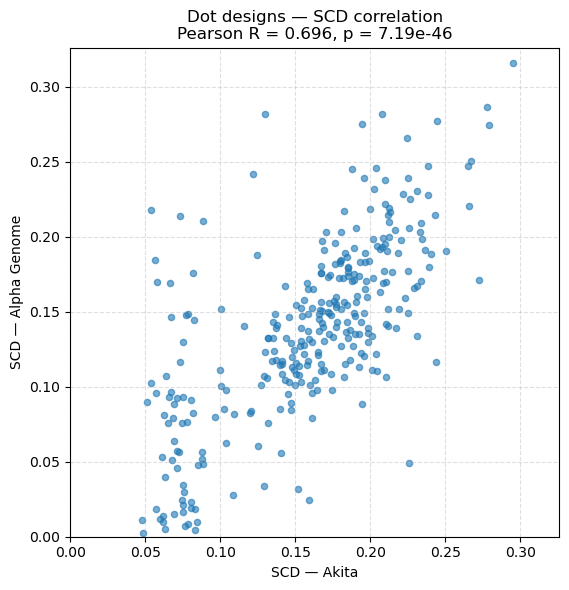

In [7]:
x = succ_df["akita_scd"].values
y = succ_df["alpha_scd"].values
r, p = pearsonr(x, y)
print(f"Pearson R = {r:.4f}, p = {p:.2e}")

lim = max(x.max(), y.max()) + 0.01

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x, y, alpha=0.6, s=20)
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("SCD — Akita")
ax.set_ylabel("SCD — Alpha Genome")
ax.set_title(f"Dot designs — SCD correlation\nPearson R = {r:.3f}, p = {p:.2e}")
ax.set_aspect("equal")
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
# plt.savefig(PLOTS_DIR / "dot_scd_akita_vs_alphagenome.svg", format="svg")
plt.show()